In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [4]:
import importlib
import package_files.benefits_defns


In [5]:
importlib.reload(package_files.benefits_defns)


<module 'package_files.benefits_defns' from '/Users/alejandracastaneda/Library/CloudStorage/OneDrive-Nexus365/SkillScale/beyond-salary/package_files/benefits_defns.py'>

In [8]:
coeff_df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_remotekw.csv')

In [29]:
coeff_df['YEAR']

array([2018, 2019, 2020, 2021, 2022, 2023])

In [9]:
coeff_df.columns

Index(['SOC_2021_2_NAME', 'YEAR', 'AI Demand', 'MEAN SALARY',
       'AI Demand % Change', 'PRIOR YEAR % CHANGE', 'LOG_SALARY_ai',
       'SALARY_ai', 'DURATION_CALC_ai', 'MEDIAN_LOG_SALARY_ai',
       'MEDIAN_SALARY_ai', 'LOG_SALARY_non_ai', 'SALARY_non_ai',
       'DURATION_CALC_non_ai', 'MEDIAN_LOG_SALARY_non_ai',
       'MEDIAN_SALARY_non_ai', 'Salary (Log) Premium', 'SALARY_PREMIUM',
       'job_count', 'Prevalence: Tuition Assistance',
       'Prevalence: Tuition Assistance (AI)',
       'Prevalence: Tuition Assistance (Non-AI)', 'Prevalence: Paid Leave',
       'Prevalence: Paid Leave (AI)', 'Prevalence: Paid Leave (Non-AI)',
       'Prevalence: Health and Wellbeing',
       'Prevalence: Health and Wellbeing (AI)',
       'Prevalence: Health and Wellbeing (Non-AI)',
       'Prevalence: Parental Leave', 'Prevalence: Parental Leave (AI)',
       'Prevalence: Parental Leave (Non-AI)', 'Prevalence: Workplace Culture',
       'Prevalence: Workplace Culture (AI)',
       'Prevalence: 

In [35]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [28]:
benefits4

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'wfh_wham',
 'REMOTE_KW']

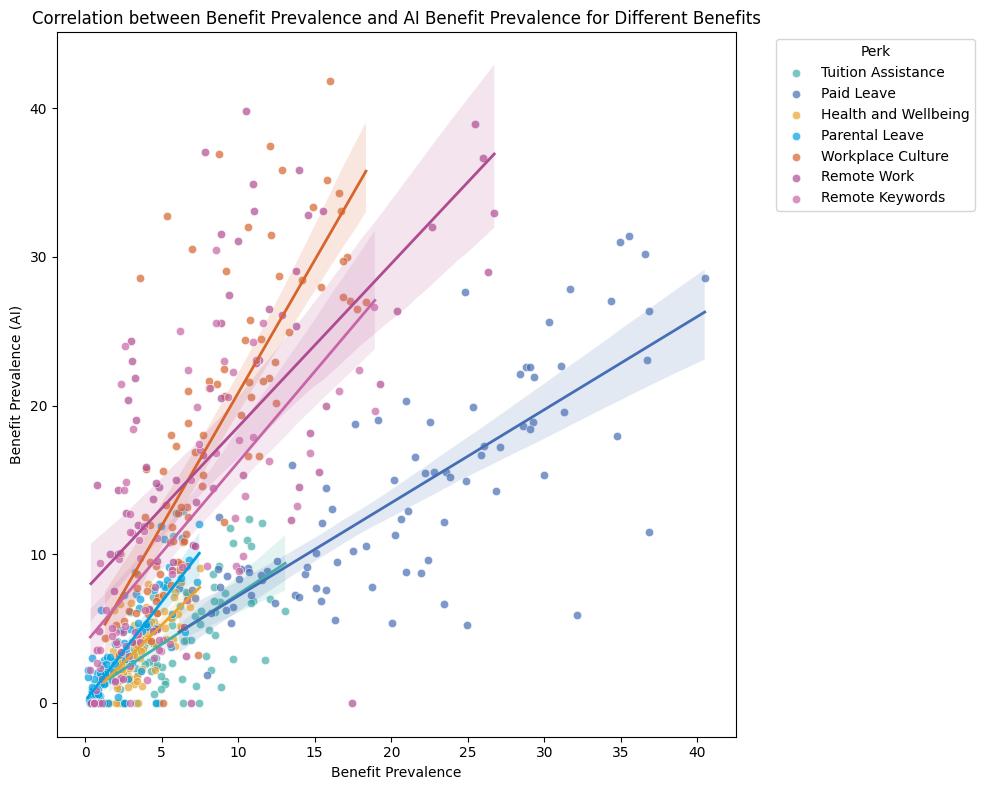

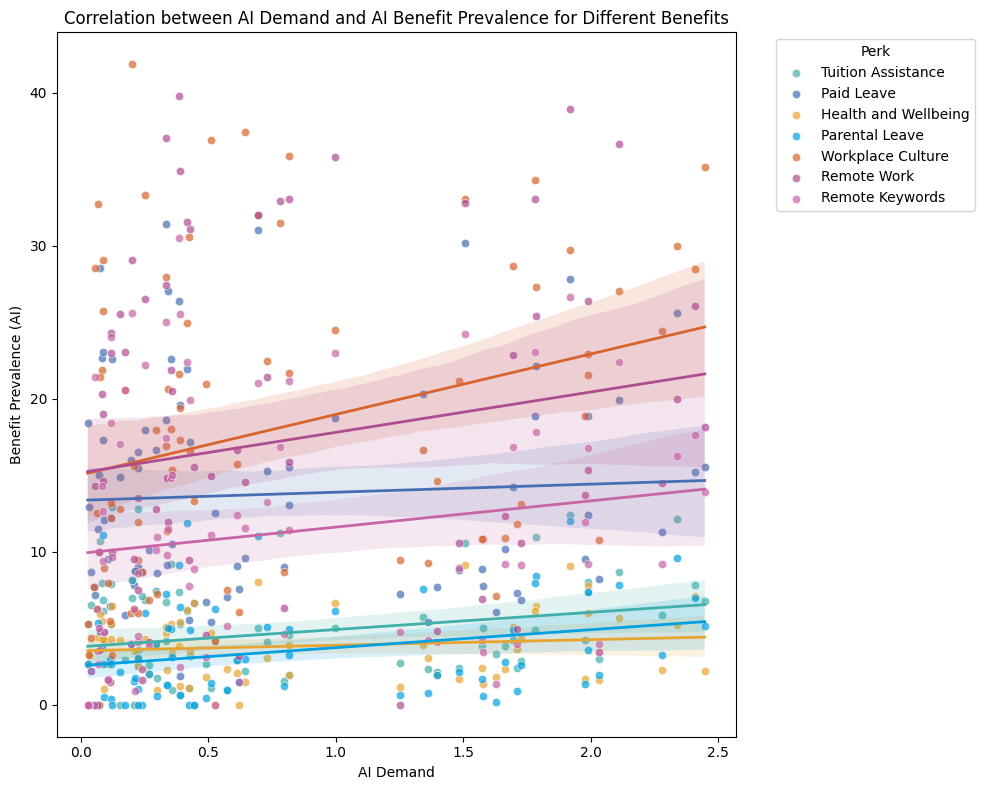

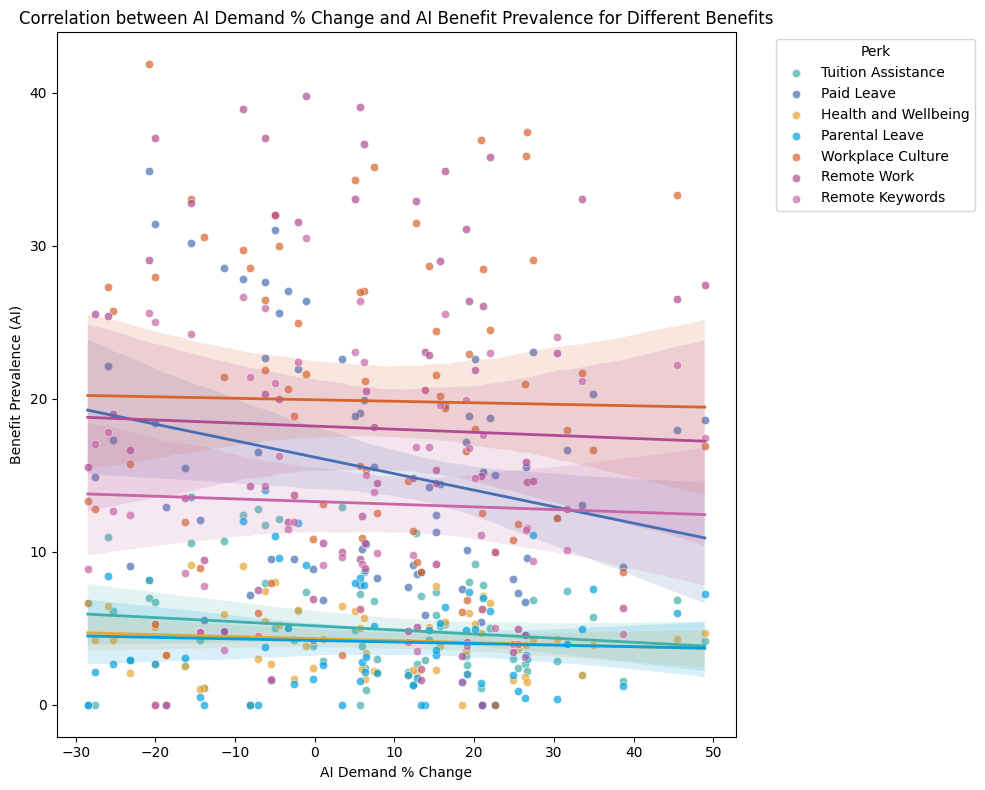

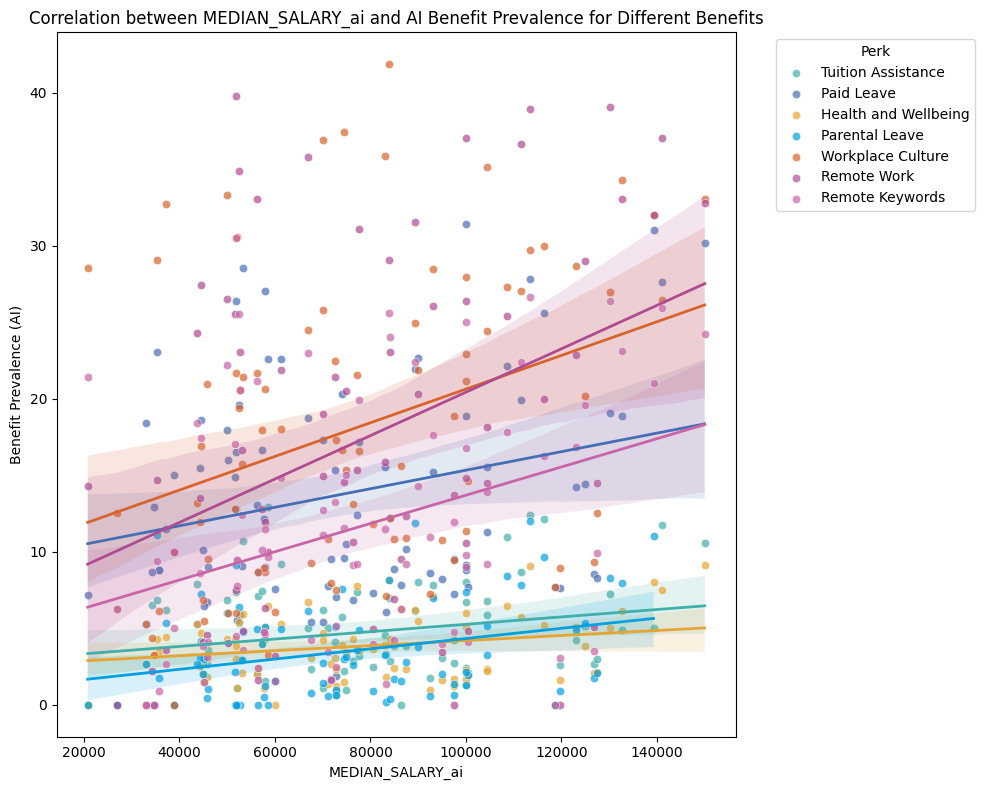

In [38]:
# Set the colors for different perks
palette = list(benefit_colors.values())

for x in range(4):
    plt.figure(figsize=(10, 8))  # Set the overall figure size
    for i, benefit in enumerate(benefits4):
        x_factors = [f'Benefit Prevalence', 'AI Demand', 'AI Demand % Change', 'MEDIAN_SALARY_ai']
        benefit_df = coeff_df[[f'Prevalence: {benefits_labels_map[benefit]} (AI)', f'Prevalence: {benefits_labels_map[benefit]}', 'AI Demand', 'AI Demand % Change', 'MEDIAN_SALARY_ai']].copy()
        benefit_df.rename(columns = {f'Prevalence: {benefits_labels_map[benefit]} (AI)': 'Benefit Prevalence (AI Roles)', f'Prevalence: {benefits_labels_map[benefit]}': 'Benefit Prevalence'}, inplace=True)
        factor = x_factors[x]
        benefit_df = benefit_df.dropna(subset=[factor, f'Benefit Prevalence (AI Roles)'])
        # Remove outliers if needed
        scatter_df = remove_outliers(benefit_df, [factor, f'Benefit Prevalence (AI Roles)']).copy()
        # scatter_df = benefit_df.copy()
        # Plot scatter points for this perk
        sns.scatterplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Benefit Prevalence (AI Roles)',
            color=palette[i],  # Use a specific color for this perk
            label=benefits4_labels[i],  # Label for the legend
            alpha=0.7      # Set some transparency for better visibility
        )

        # Plot a fitted line (regression) for this perk
        sns.regplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Benefit Prevalence (AI Roles)',
            scatter=False,      # No scatter points for the regression line
            color=palette[i],   # Set the color to match the perk
            line_kws={'label': benefits4_labels[i], 'linewidth': 2}  # Add the perk label to the fitted line
        )

    # Add labels and title to the combined plot
    plt.xlabel(factor)
    plt.ylabel('Benefit Prevalence (AI)')
    plt.title(f'Correlation between {factor} and AI Benefit Prevalence for Different Benefits')

    # Add a legend that shows the perks
    plt.legend(title='Perk', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Display the final combined plot
    plt.tight_layout()
    plt.savefig('../figures/scatterplot/scatterplot_pct_' + factor + '.png')
    plt.show()


# Raw Numbers

In [7]:
df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_2024_raw.csv')

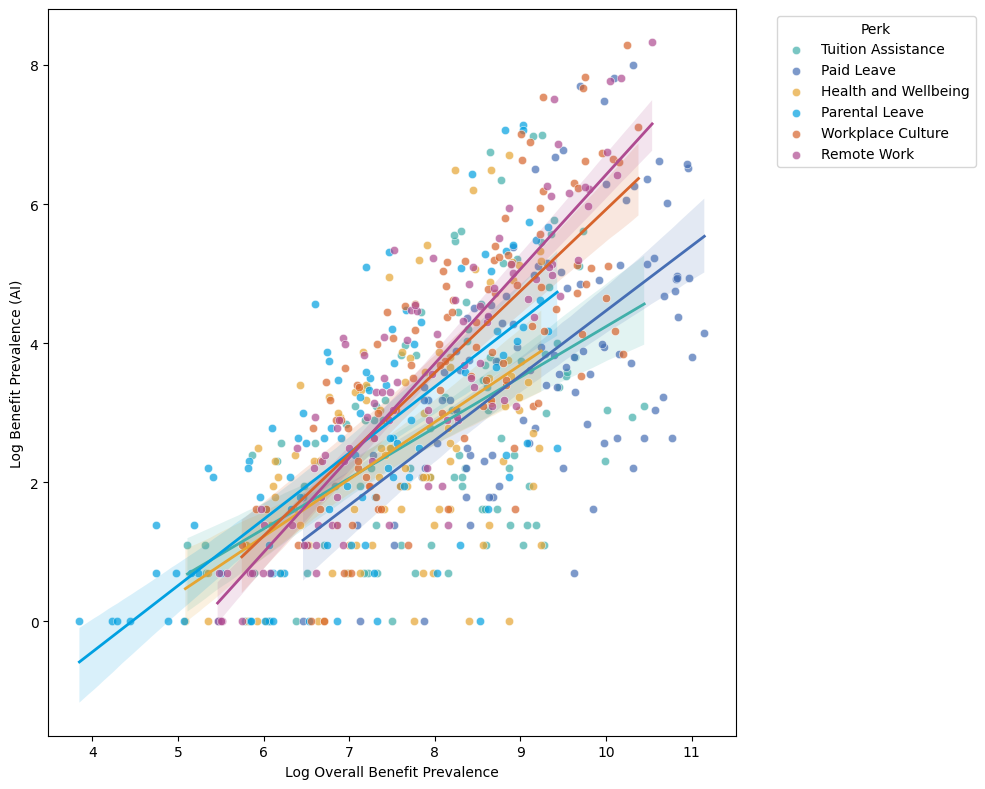

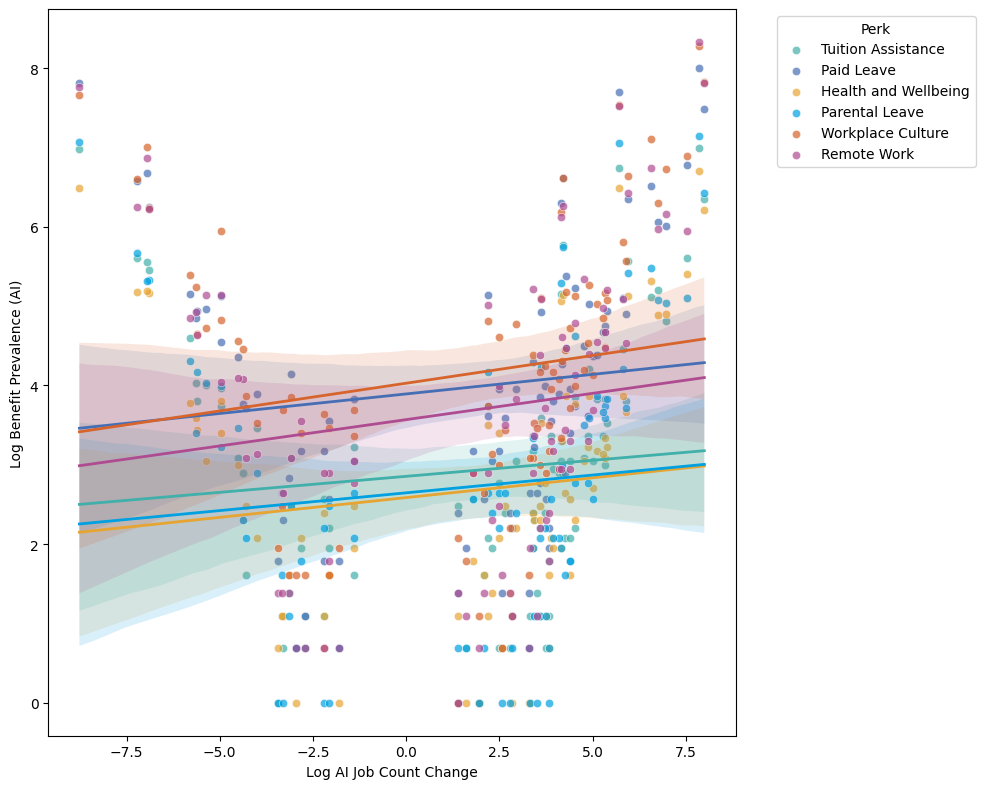

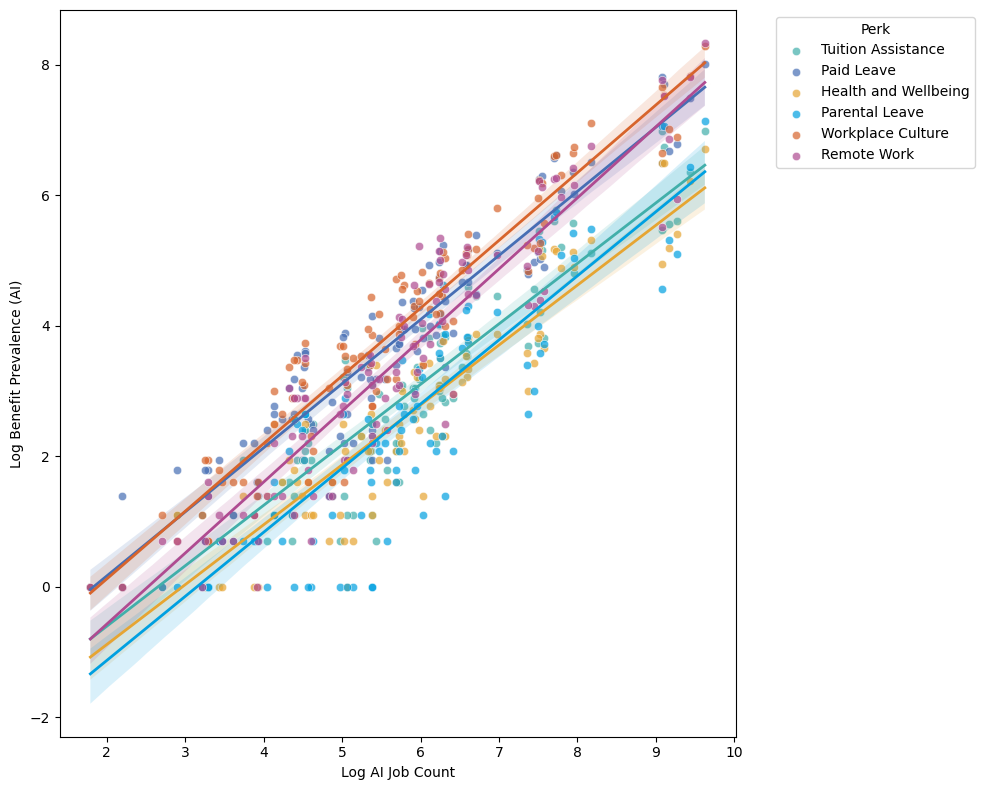

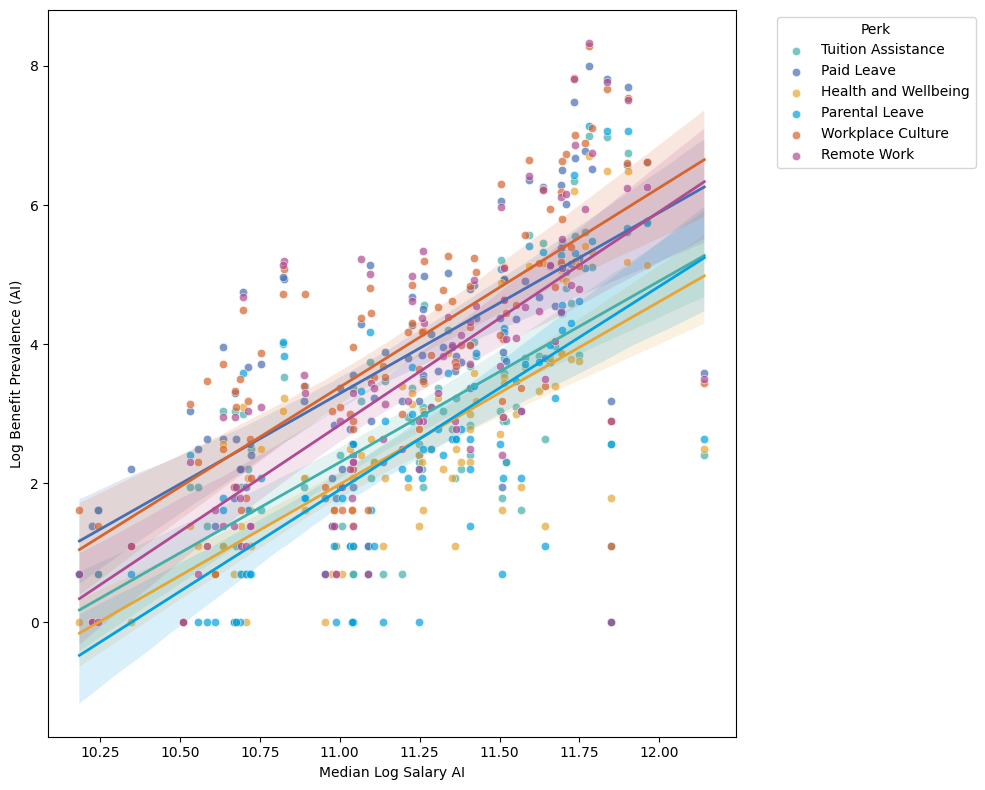

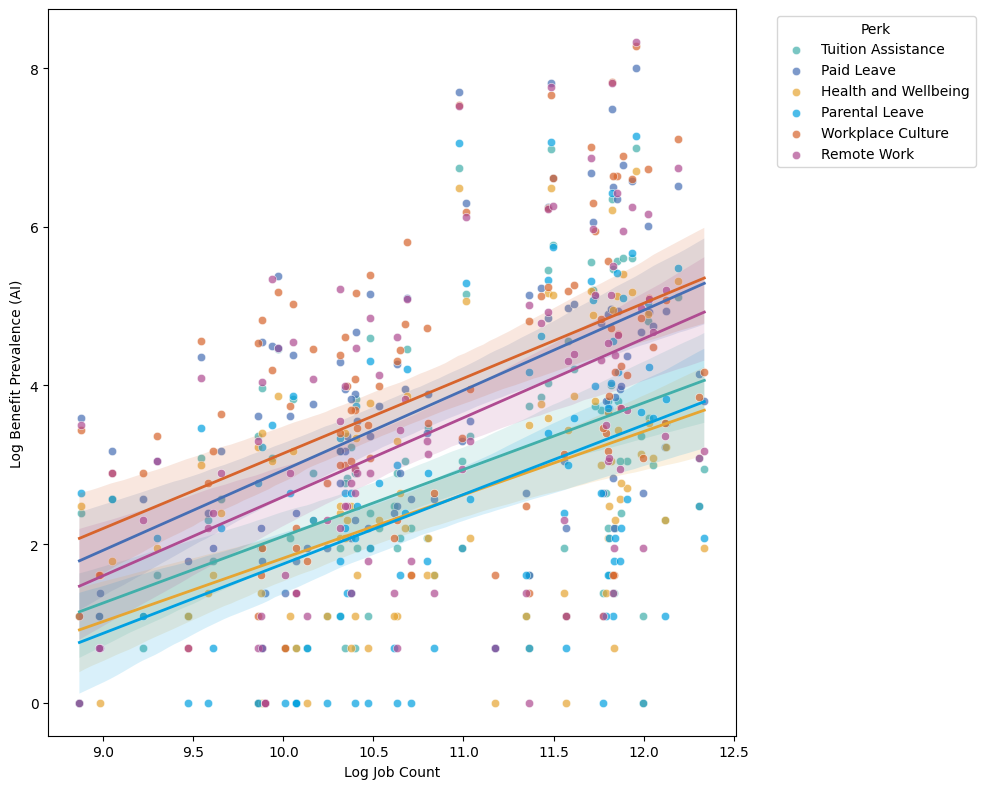

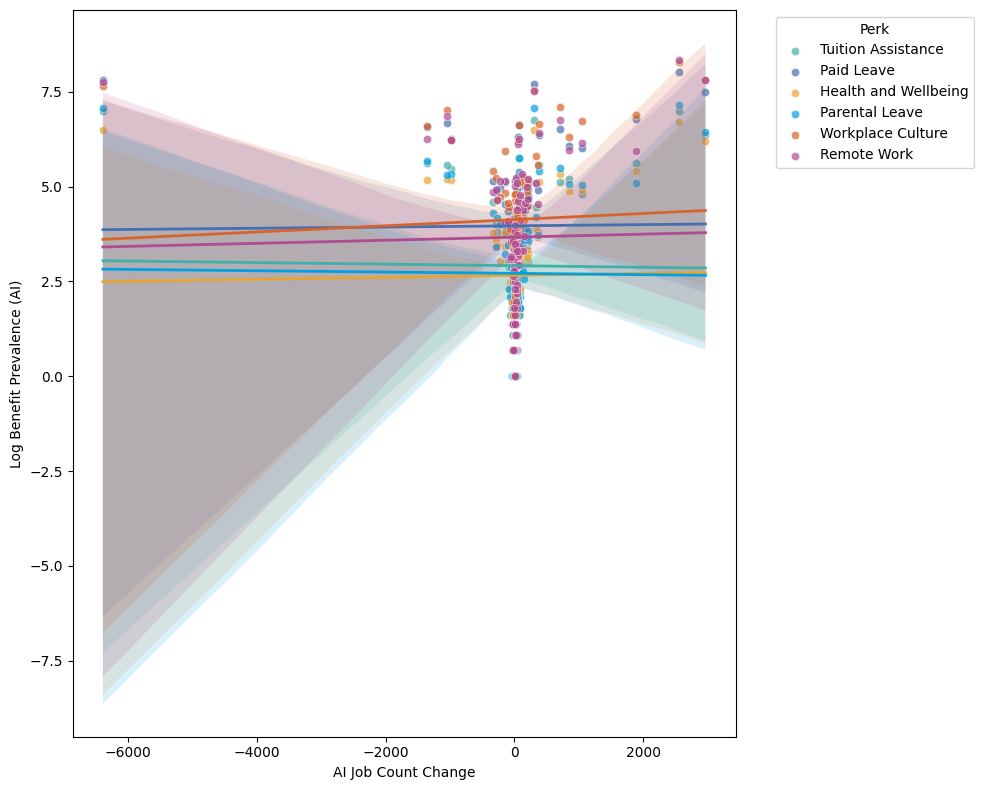

In [23]:
# Set the colors for different perks
palette = list(benefit_colors.values())

for x in range(6):
    plt.figure(figsize=(10, 8))  # Set the overall figure size
    for i, benefit in enumerate(benefits4):
        benefit_df = df.copy()
        benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
        benefit_df.rename(columns = {f'Prevalence: {benefits_labels_map[benefit]} (AI)': 'Benefit Prevalence (AI Roles)'}, inplace=True)
        label = benefits_labels_map[benefit]
        benefit_df.rename(columns = {f'ai_role_count': 'AI Job Count', 'MEDIAN_LOG_SALARY_ai': 'Median Log Salary AI'}, inplace=True)
        log_cols = [f'Overall Benefit Prevalence', 'AI Job Count Change','AI Job Count', f'Benefit Prevalence (AI Roles)']
        for col in log_cols:
            benefit_df[f'Log {col}'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
        x_factors = [f'Log {col}' for col in log_cols[:-1]] + ['Median Log Salary AI', 'Log Job Count', 'AI Job Count Change'] 
        factor = x_factors[x]
        benefit_df = benefit_df.dropna(subset=[factor, f'Log Benefit Prevalence (AI Roles)'])
        # Remove outliers if needed
        # scatter_df = remove_outliers(benefit_df, [factor, f'Benefit Prevalence (AI Roles)']).copy()
        scatter_df = benefit_df.copy()
        # Plot scatter points for this perk
        sns.scatterplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Log Benefit Prevalence (AI Roles)',
            color=palette[i],  # Use a specific color for this perk
            label=benefits4_labels[i],  # Label for the legend
            alpha=0.7      # Set some transparency for better visibility
        )

        # Plot a fitted line (regression) for this perk
        sns.regplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Log Benefit Prevalence (AI Roles)',
            scatter=False,      # No scatter points for the regression line
            color=palette[i],   # Set the color to match the perk
            line_kws={'label': benefits4_labels[i], 'linewidth': 2}  # Add the perk label to the fitted line
        )

    # Add labels and title to the combined plot
    plt.xlabel(factor)
    plt.ylabel('Log Benefit Prevalence (AI)')
    # plt.title(f'Correlation between {factor} and AI Benefit Prevalence for Different Benefits')

    # Add a legend that shows the perks
    plt.legend(title='Perk', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Display the final combined plot
    plt.tight_layout()
    plt.savefig('../figures/scatterplot/scatterplot_log_' + factor + '.png')
    plt.show()
